# BUSINESS UNDERSTANDING

We at K-Means Kapital ltd have been tasked with a dataset from a leading telecommunications provider who is undergoing some challenges and would wish to us to conduct an analysis from their customer data.

The challenge that Syriatel is facing s that they are losing customers and ultimately impacting their revenues. 

What we shall do for this data is to conduct an analysis on the usage trends and ultimately help predict potentially exiting customers that way they may be able to have a better picture of their busness health going forward.

# PROBLEM STATEMENT

With the provided variables(though only the necessary ones shall be picked), 

('state','account length','area code','phone number','international plan','voice mail plan','number vmail messages','total day minutes','total day calls','total day charge','total eve minutes','total eve calls','total eve charge','total night minutes','total night calls','total night charge','total intl minutes','total intl calls','total intl charge','customer service calls','churn')

We aim to conduct an anlaysis provide a model to help them reduce churn and retain clientelle 

# OBJECTIVES

#### 1.

1. Build a classification model to predict the churn rate 
2. Improve predictive accuracy

# DATA UNDERSTANDING

In [2]:
#Let's load some essential modules for the initial steps
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('syriatel.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
#getting summary statistics on the columns
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [5]:
#getting information on the columns data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

From the above we can determine that;
1. Our data contains 3,333 entries(rows)
2. 21 columns in total (4 objects, 1 bool, 8 floats, 8 int columns)

# DATA CLEANING & PREPARATION 

### Handling NAs & Duplicates

In [6]:
#let's check for missing values
print(df.isna().sum())
print(f'Duplicated values are:  ',{df.duplicated().sum()})

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64
Duplicated values are:   {0}


We have no missing data points which is good as we can assume that the data is complete and can get insights without having to worry about values to add.

We have no duplicated values and as such we can proceed.

### Droping unncessary columns

In [7]:
#we have selected the three columns below as these are identifiers and would not carry much weight in the analysis
df.drop(columns=['area code','phone number','state'],inplace=True)

### Feature Engineering

# EXPLORATORY DATA ANALYSIS (EDA)

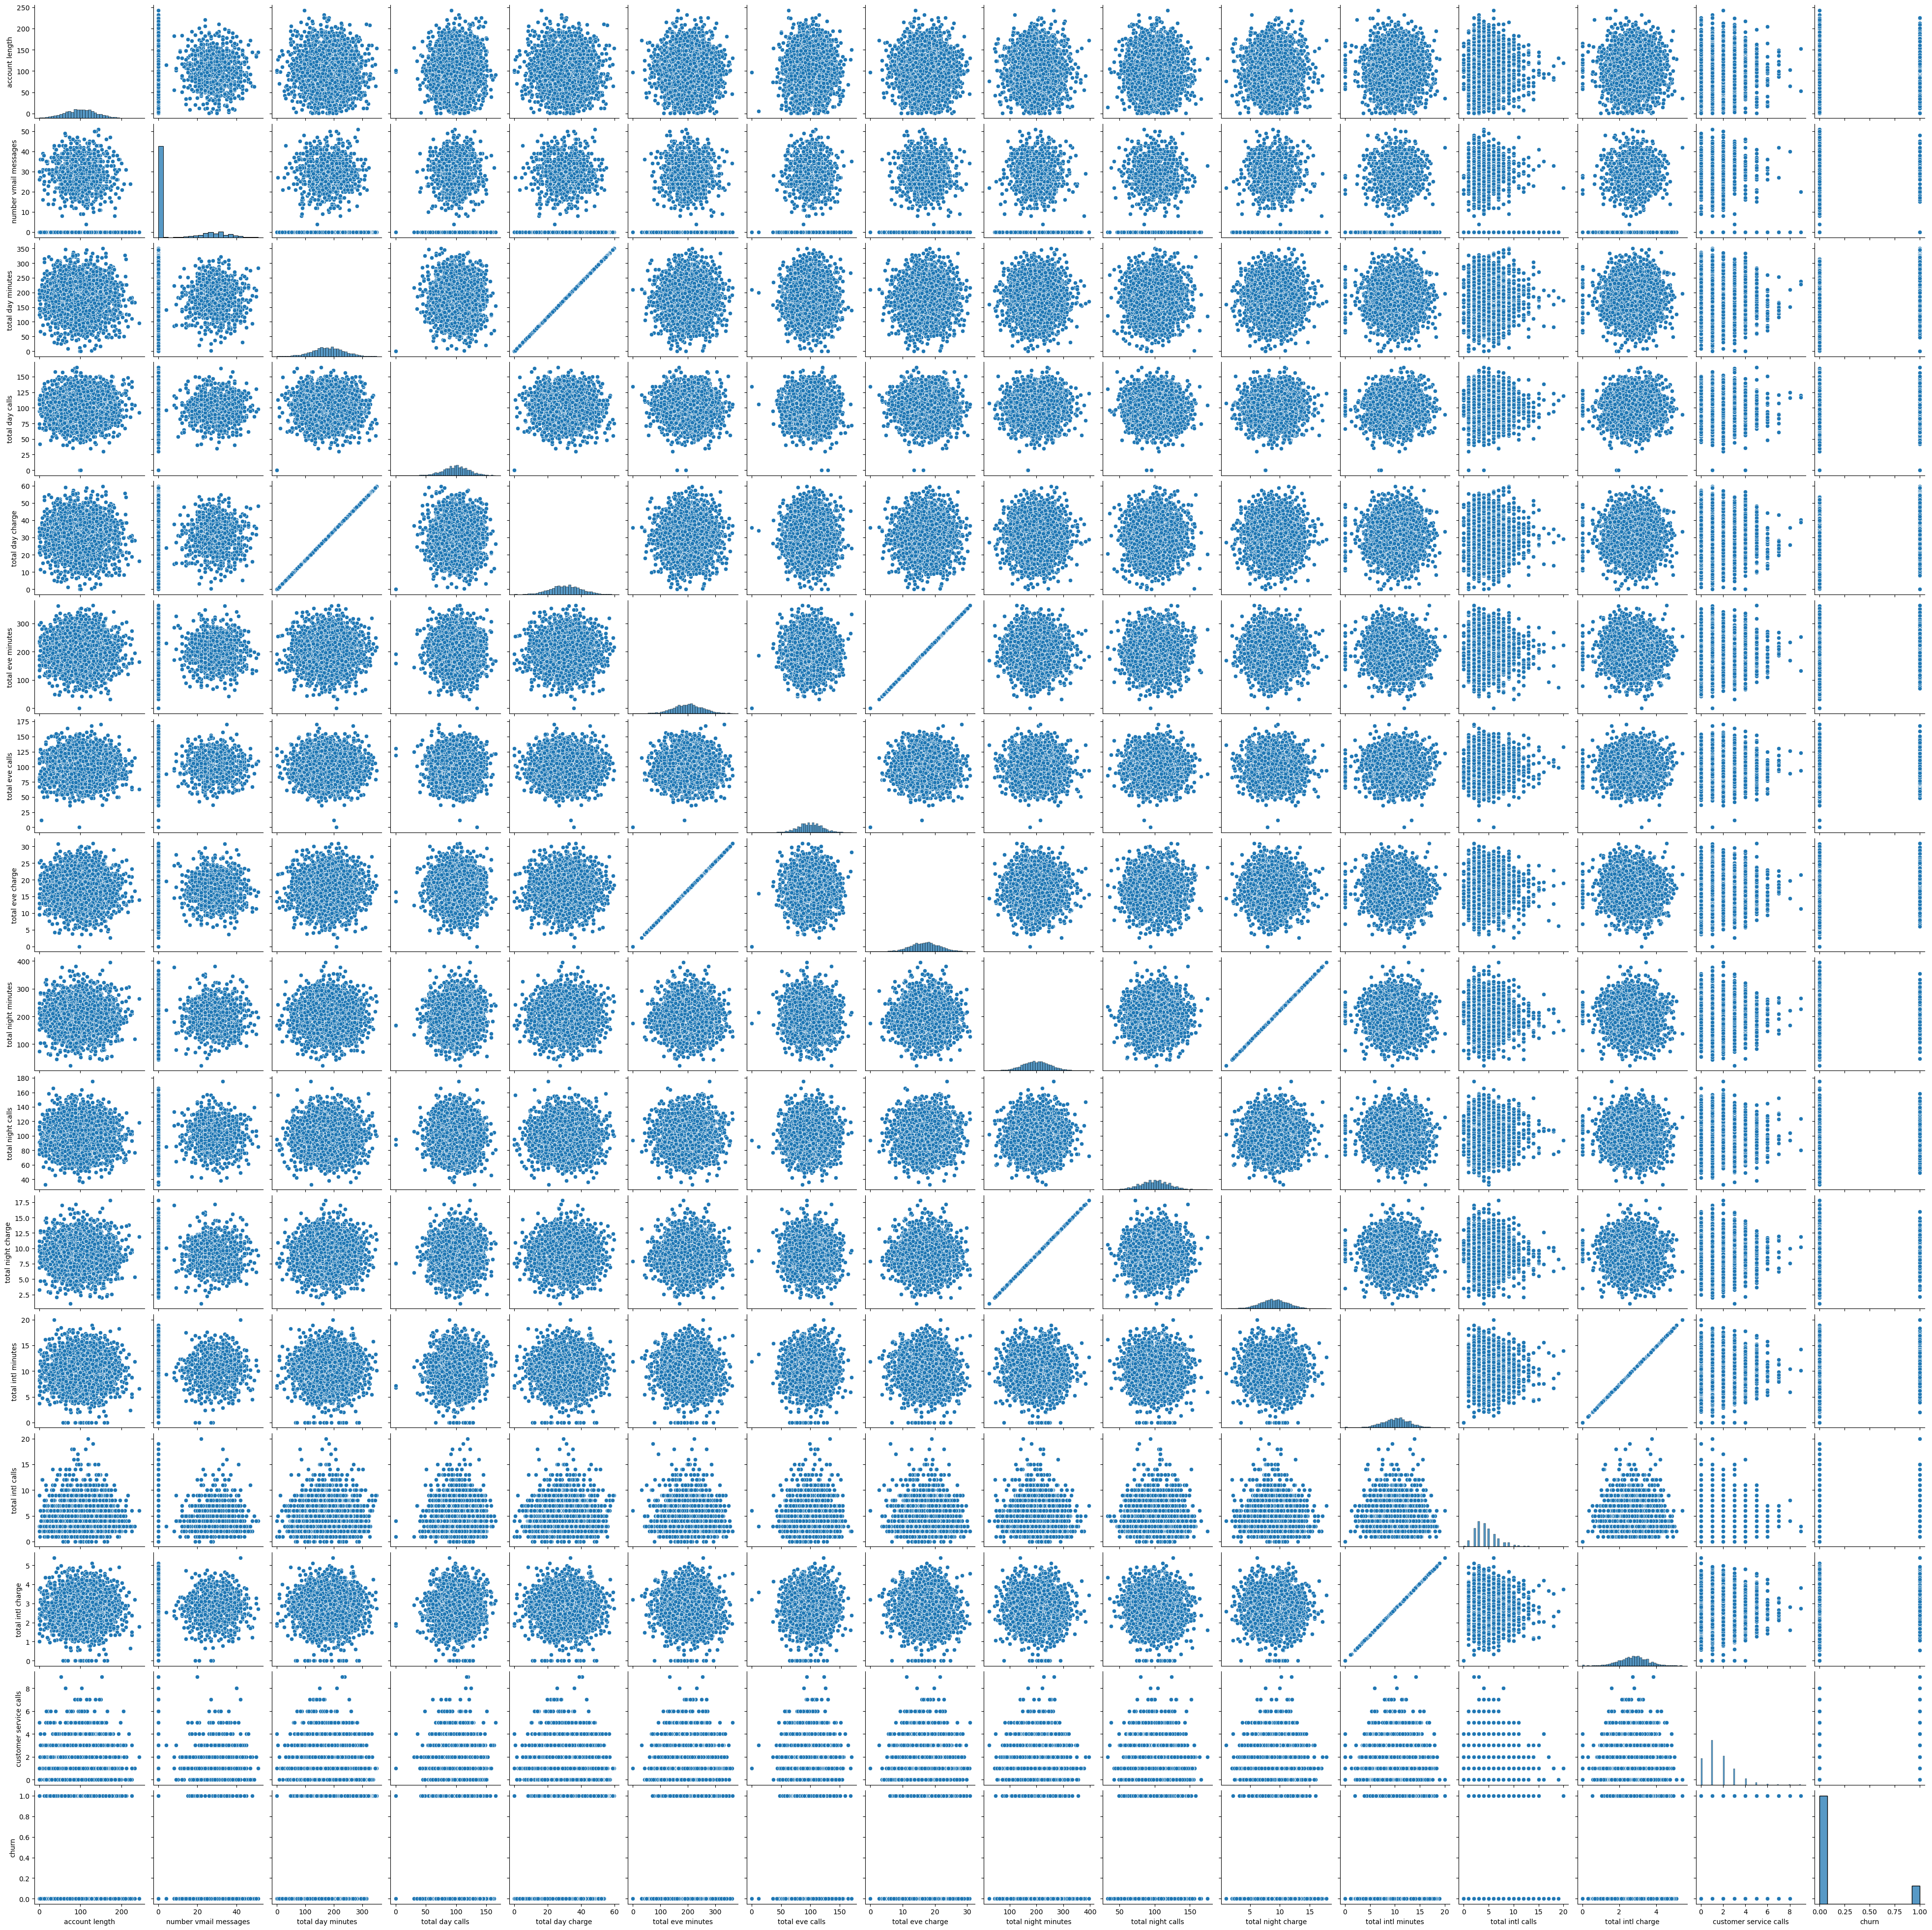

In [8]:
#lets perform a pair plot to get an overview of the relationships between the variables
sns.pairplot(df)

In [9]:
#check for unique values in the columns
df.nunique()

account length             212
international plan           2
voice mail plan              2
number vmail messages       46
total day minutes         1667
total day calls            119
total day charge          1667
total eve minutes         1611
total eve calls            123
total eve charge          1440
total night minutes       1591
total night calls          120
total night charge         933
total intl minutes         162
total intl calls            21
total intl charge          162
customer service calls      10
churn                        2
dtype: int64

##### let's visualize the unique values in the categorical variables, i.e the ones with the least number of unique variables.

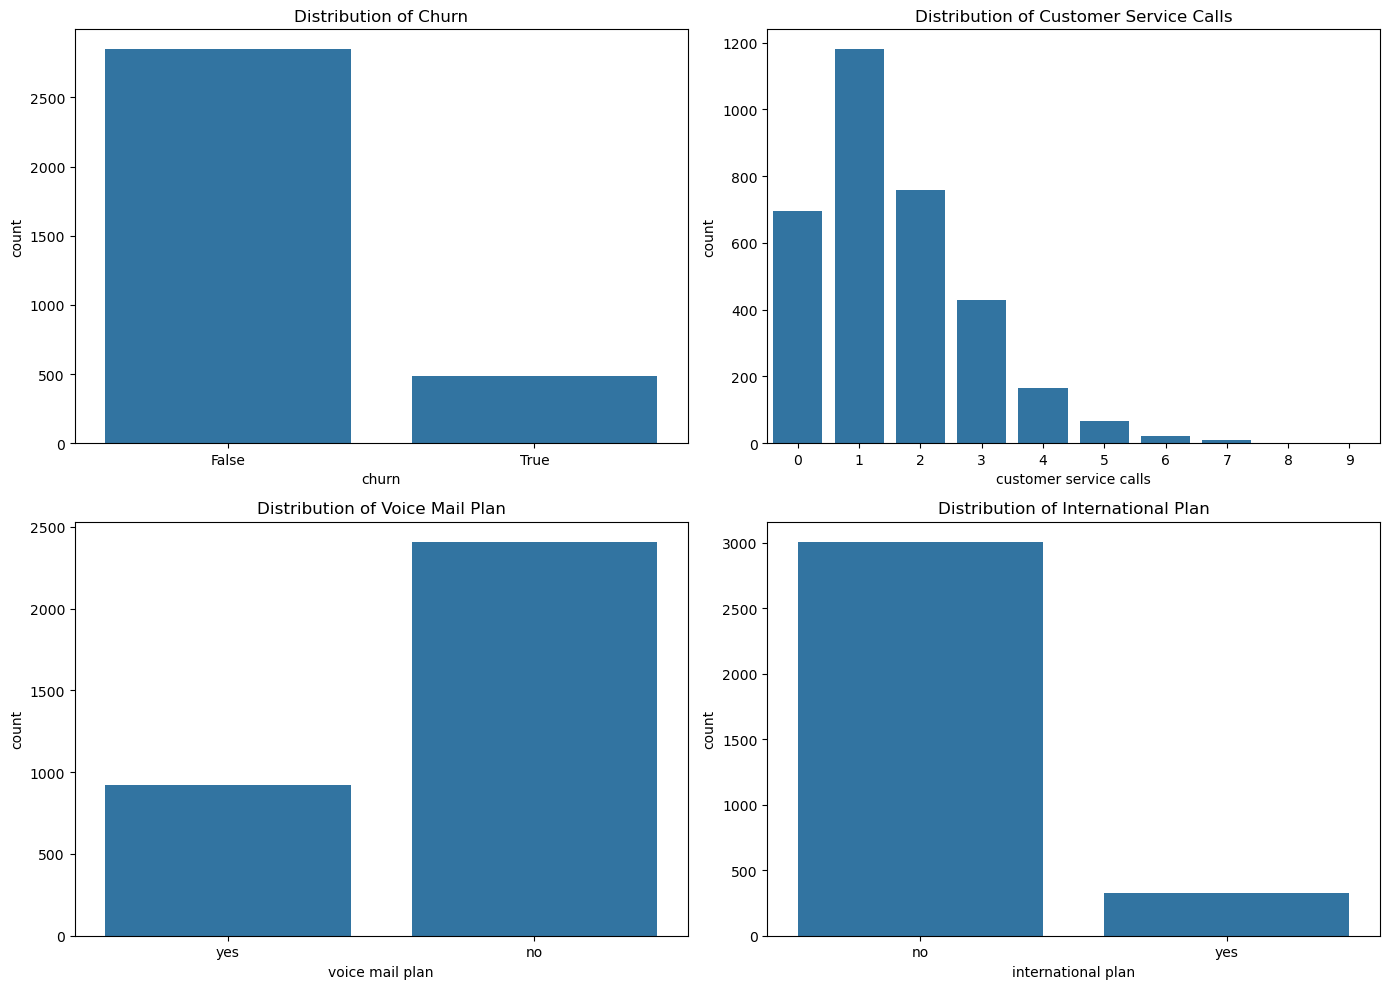

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot for churn
sns.countplot(ax=axes[0, 0], x='churn', data=df)
axes[0, 0].set_title('Distribution of Churn')

# Plot for customer service calls
sns.countplot(ax=axes[0, 1], x='customer service calls', data=df)
axes[0, 1].set_title('Distribution of Customer Service Calls')

# Plot for voice mail plan
sns.countplot(ax=axes[1, 0], x='voice mail plan', data=df)
axes[1, 0].set_title('Distribution of Voice Mail Plan')

# Plot for international plan
sns.countplot(ax=axes[1, 1], x='international plan', data=df)
axes[1, 1].set_title('Distribution of International Plan')

plt.tight_layout()
plt.show()

In [11]:
x= ['churn','voice mail plan','international plan','customer service calls']

#to check the distribution
for i in x:
    print(df[i].value_counts())


churn
False    2850
True      483
Name: count, dtype: int64
voice mail plan
no     2411
yes     922
Name: count, dtype: int64
international plan
no     3010
yes     323
Name: count, dtype: int64
customer service calls
1    1181
2     759
0     697
3     429
4     166
5      66
6      22
7       9
9       2
8       2
Name: count, dtype: int64


From the above plot and value count analysis we can see that out of 3,333 customers;
1. Churn - (2850 remained , 483 left)
2. Voicemail Plan - (922 have it, 2411 don't)
3. International plan - (323 have it, 3010 don't)
4. Customer service calls - (about 20% of clientelle haven't made a call but most issues appear to be solved by the third/fourth call or these could be different scenario calls.)

In [12]:
print('As percentages of the total')
#to check the percentages
for i in x:
    print(df[i].value_counts(normalize=True)*100)

As percentages of the total
churn
False    85.508551
True     14.491449
Name: proportion, dtype: float64
voice mail plan
no     72.337234
yes    27.662766
Name: proportion, dtype: float64
international plan
no     90.309031
yes     9.690969
Name: proportion, dtype: float64
customer service calls
1    35.433543
2    22.772277
0    20.912091
3    12.871287
4     4.980498
5     1.980198
6     0.660066
7     0.270027
9     0.060006
8     0.060006
Name: proportion, dtype: float64


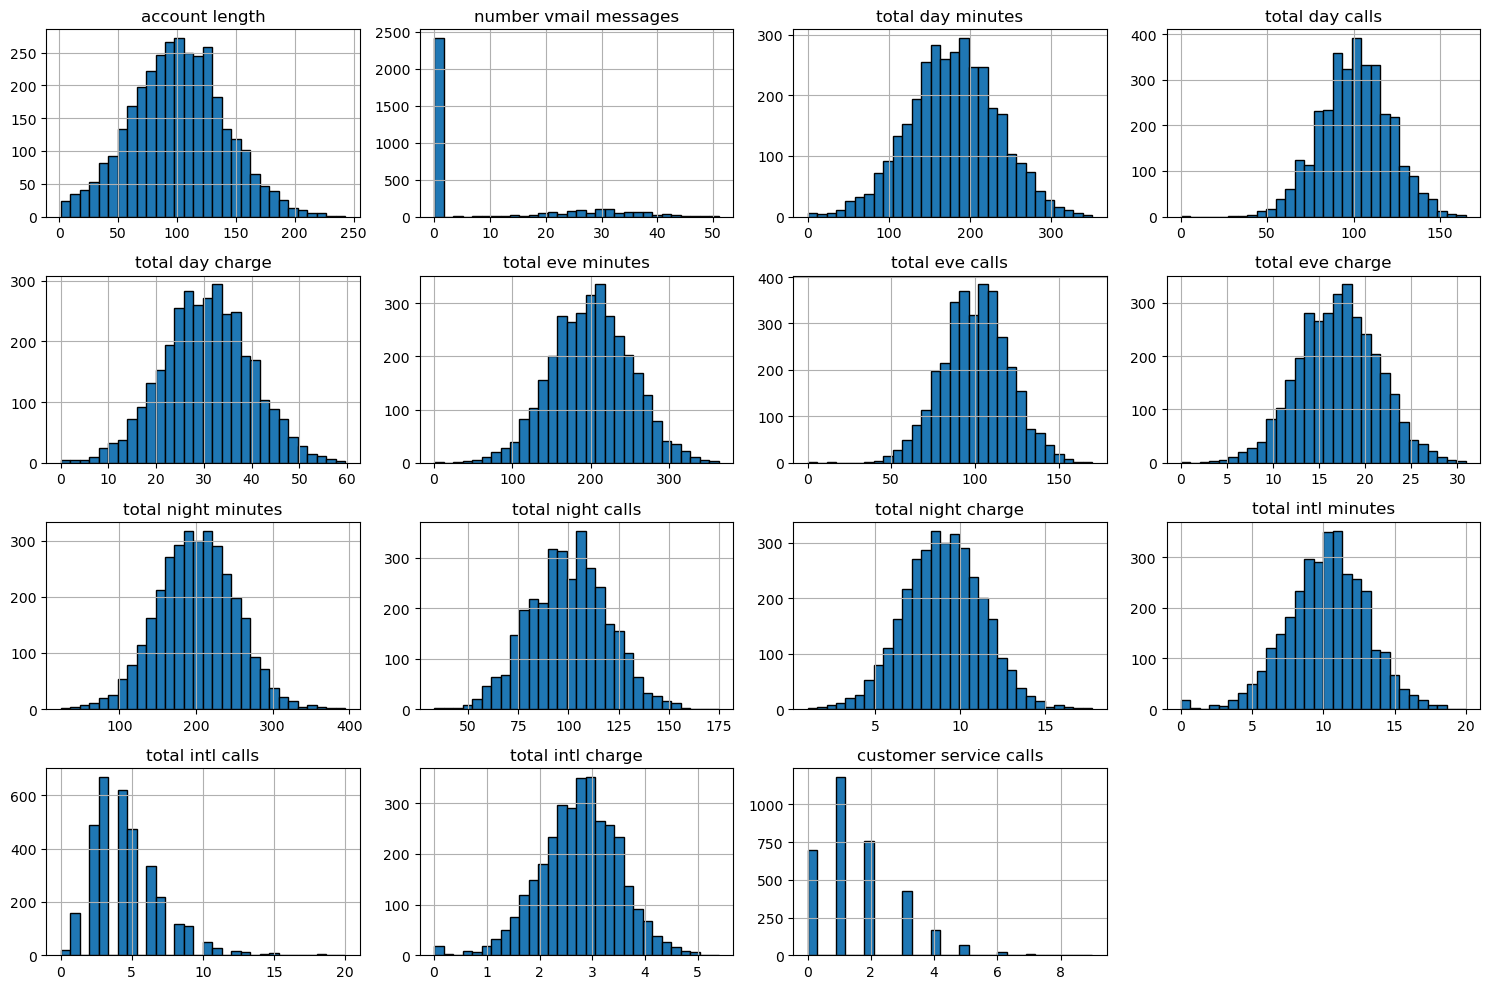

In [13]:
# Plot histograms for each numerical column
df.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()

From the above we can see normal distribution in the following columns;
1. account length is normally distributed - 1 
2. total international (calls, charge,minutes) are normarlly distributed - 3
3. total night (minutes, calls, and charge) are normally distributed - 3
4. total evening (minutes, calls, and charge) are normally distributed - 3
5. total day (minutes, calls, and charge) are normally distributed - 3

** These normally distributed values may come in handy later in the analysis **

### Univariate Analysis

In [14]:
#Let's generate a correllation matrix to better understand the relationship between our variables.
corr_matrix = df.select_dtypes(include='number').corr()
corr_matrix

,account length,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
account length,1.000000,-0.004628,0.006216,0.038470,0.006214,-0.006757,0.019260,-0.006745,-0.008955,-0.013176,-0.008960,0.009514,0.020661,0.009546,-0.003796
number vmail messages,-0.004628,1.000000,0.000778,-0.009548,0.000776,0.017562,-0.005864,0.017578,0.007681,0.007123,0.007663,0.002856,0.013957,0.002884,-0.013263
total day minutes,0.006216,0.000778,1.000000,0.006750,1.000000,0.007043,0.015769,0.007029,0.004323,0.022972,0.004300,-0.010155,0.008033,-0.010092,-0.013423
total day calls,0.038470,-0.009548,0.006750,1.000000,0.006753,-0.021451,0.006462,-0.021449,0.022938,-0.019557,0.022927,0.021565,0.004574,0.021666,-0.018942
total day charge,0.006214,0.000776,1.000000,0.006753,1.000000,0.007050,0.015769,0.007036,0.004324,0.022972,0.004301,-0.010157,0.008032,-0.010094,-0.013427
total eve minutes,-0.006757,0.017562,0.007043,-0.021451,0.007050,1.000000,-0.011430,1.000000,-0.012584,0.007586,-0.012593,-0.011035,0.002541,-0.011067,-0.012985
total eve calls,0.019260,-0.005864,0.015769,0.006462,0.015769,-0.011430,1.000000,-0.011423,-0.002093,0.007710,-0.002056,0.008703,0.017434,0.008674,0.002423
total eve charge,-0.006745,0.017578,0.007029,-0.021449,0.007036,1.000000,-0.011423,1.000000,-0.012592,0.007596,-0.012601,-0.011043,0.002541,-0.011074,-0.012987
total night minutes,-0.008955,0.007681,0.004323,0.022938,0.004324,-0.012584,-0.002093,-0.012592,1.000000,0.011204,0.999999,-0.015207,-0.012353,-0.015180,-0.009288
total night calls,-0.013176,0.007123,0.022972,-0.019557,0.022972,0.007586,0.007710,0.007596,0.011204,1.000000,0.011188,-0.013605,0.000305,-0.013630,-0.012802


<Axes: >

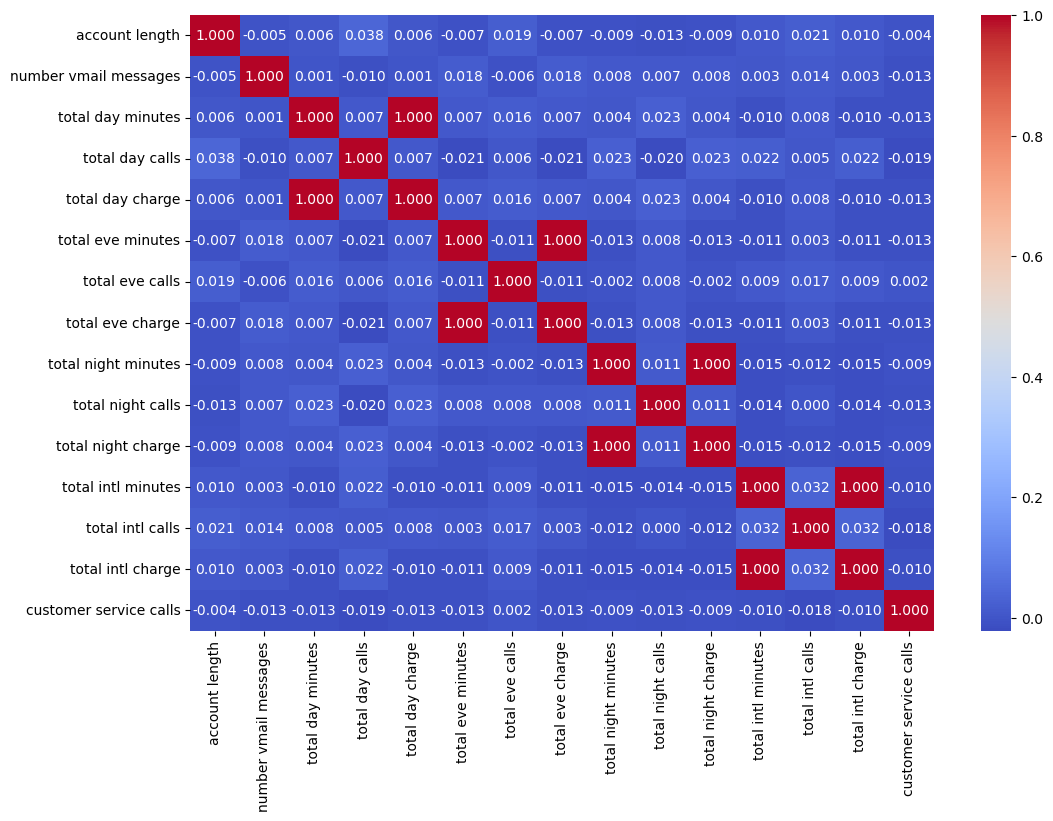

In [15]:
#Because the above data is cramped, let's visualize the same.
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.3f')

<Axes: >

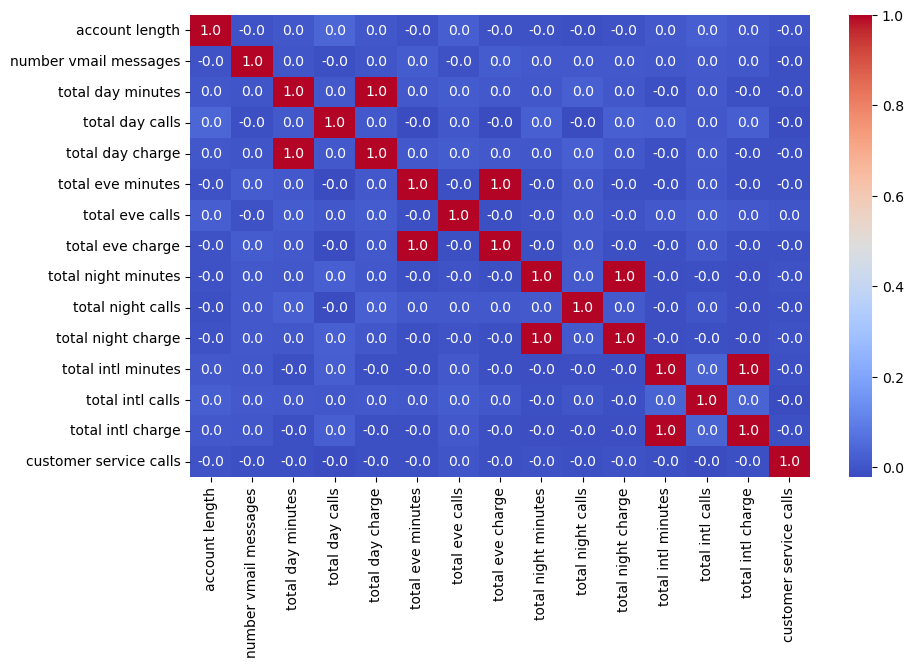

In [16]:
#Let' redo the above but with a single decimal place to better see those that stand out.
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.1f')


From the above we can see that their are practically no correlations between the numeric variables.

### Bi-Variate Analysis

We shall work with the churn column vs customer service, international plan and voice mail plan and account duration

Churn vs customer service calls

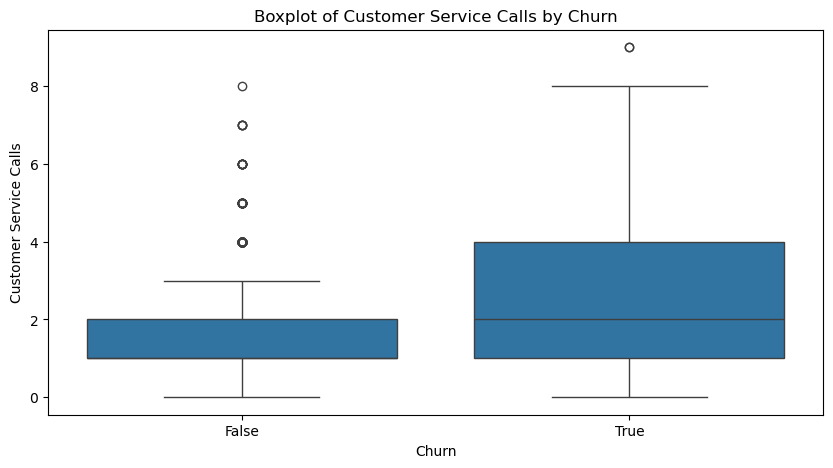

In [17]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='churn', y='customer service calls')
plt.title('Boxplot of Customer Service Calls by Churn')
plt.xlabel('Churn')
plt.ylabel('Customer Service Calls')
plt.show()

In [18]:
df[['churn', 'customer service calls']].corr()


,churn,customer service calls
churn,1.00000,0.20875
customer service calls,0.20875,1.00000


From the above we can deduce that the customers that left had complaints that were raised with the customer care desk, this also points to a 20% correlation between calls and churn

Churn vs. International plan

In [19]:
#We need to change the format for international plan column and create a new column as we can't correalte yes and no columns 
df['international plan1'] = df['international plan'].map({'yes': 1, 'no': 0})

#to do the correaltion
df[['churn', 'international plan1']].corr()


,churn,international plan1
churn,1.000000,0.259852
international plan1,0.259852,1.000000


As we can see above there is a greater correlation between the churn from the customers with international plans comin in at 25%, we could potentially say that maybe they found better costs but further analysis required.

Churn vs voicemail plan

In [20]:
#We need to change the format for voice mail plan column and create a new column as we can't correalte yes and no columns 
df['voice mail plan1'] = df['voice mail plan'].map({'yes': 1, 'no': 0})

#to do the correaltion
df[['churn', 'voice mail plan1']].corr()

,churn,voice mail plan1
churn,1.000000,-0.102148
voice mail plan1,-0.102148,1.000000


At -10% correlation, we can positively conclude that voice mail plan is not a deciding factor on the churn and as such we shall not draw conclusions from this 

Churn vs account length

In [21]:
#We shall assume that account length refers to months on the service.

#to do the correaltion
df[['churn', 'account length']].corr()

,churn,account length
churn,1.000000,0.016541
account length,0.016541,1.000000


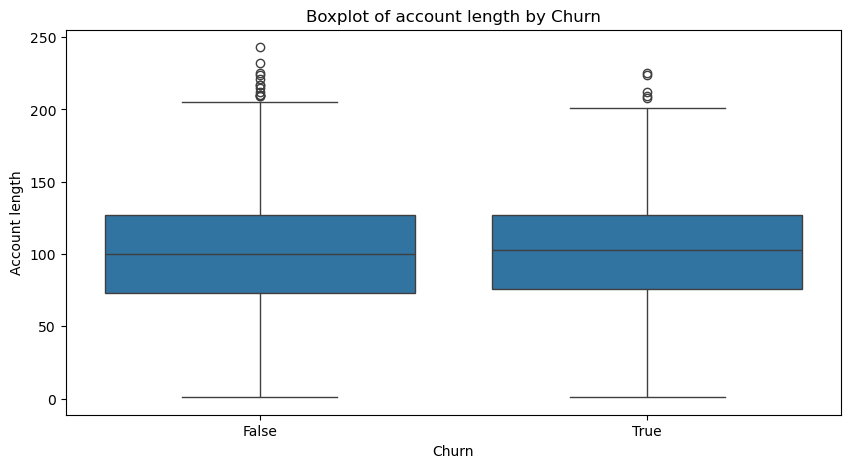

In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='churn', y='account length')
plt.title('Boxplot of account length by Churn')
plt.xlabel('Churn')
plt.ylabel('Account length')
plt.show()

From the above analysis, we can further proceed to conclude that the duration of the account does  not affect churn and as such customer loyalty isn't an influential factor in this case with only a 1.6% correlation

### Multi-variate Analysis

# PRE-PROCESSING

In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account length          3333 non-null   int64  
 1   international plan      3333 non-null   object 
 2   voice mail plan         3333 non-null   object 
 3   number vmail messages   3333 non-null   int64  
 4   total day minutes       3333 non-null   float64
 5   total day calls         3333 non-null   int64  
 6   total day charge        3333 non-null   float64
 7   total eve minutes       3333 non-null   float64
 8   total eve calls         3333 non-null   int64  
 9   total eve charge        3333 non-null   float64
 10  total night minutes     3333 non-null   float64
 11  total night calls       3333 non-null   int64  
 12  total night charge      3333 non-null   float64
 13  total intl minutes      3333 non-null   float64
 14  total intl calls        3333 non-null   

In [24]:
#let's create lists to split the numerical and object columns

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
object_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", numeric_cols)
print('Object columns:', object_cols)

Numerical columns: ['account length', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls', 'international plan1', 'voice mail plan1']
Object columns: ['international plan', 'voice mail plan', 'churn']


### Encoding

We shall work on the object columns to enable us conduct modeling


In [25]:
df[object_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   international plan  3333 non-null   object
 1   voice mail plan     3333 non-null   object
 2   churn               3333 non-null   bool  
dtypes: bool(1), object(2)
memory usage: 55.5+ KB


In [26]:
#let's check for the unique variable in each column to enable us decide which encoding we shall applyh to the columns

for i in object_cols:
  print(f'The variable "{i}" has {df[i].nunique()} variables: {df[i].unique()} \n')

The variable "international plan" has 2 variables: ['no' 'yes'] 

The variable "voice mail plan" has 2 variables: ['yes' 'no'] 

The variable "churn" has 2 variables: [False  True] 



From the above our work is cut out for us and we shall proceed to use label encoding for the above columns

In [27]:
#lets make a copy that way we do not tamper with the original data
df_encoded = df.copy()

In [28]:
#we shall first begin with the boolean column 
# Convert boolean columns to numeric (0 and 1)
for col in df_encoded.select_dtypes(include='bool'):
    df_encoded[col] = df_encoded[col].astype(int)
df_encoded.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,international plan1,voice mail plan1
0,128,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0,0,1
1,107,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0,0,1
2,137,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,0,0
3,84,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0,1,0
4,75,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0,1,0


In [29]:
#now let's handle the plan columns
df_encoded['international plan'] = df_encoded['international plan'].map({'no': 0, 'yes': 1})

df_encoded['voice mail plan'] = df_encoded['voice mail plan'].map({'no': 0, 'yes': 1})

In [30]:
# to check it worked

for i in object_cols:
  print(f'The variable "{i}" has {df_encoded[i].nunique()} variables: {df_encoded[i].unique()} \n')


The variable "international plan" has 2 variables: [0 1] 

The variable "voice mail plan" has 2 variables: [1 0] 

The variable "churn" has 2 variables: [0 1] 



We have successfully encoded the variables and we can now proceed over to scaling.

### Scaling

In [31]:
#Let's isolate the numeric columns
numeric_columns = df_encoded.select_dtypes(include=np.number).columns.tolist()

for i, col in enumerate(numeric_columns):
    print(numeric_columns[i],'  :   ' ,df_encoded[col].skew())

account length   :    0.09660629423135147
international plan   :    2.7263316038885086
voice mail plan   :    0.9991395548141272
number vmail messages   :    1.2648236337102594
total day minutes   :    -0.029077067143188955
total day calls   :    -0.11178663903979906
total day charge   :    -0.029083268343274994
total eve minutes   :    -0.023877456078123447
total eve calls   :    -0.05556313904148763
total eve charge   :    -0.02385798900760956
total night minutes   :    0.008921291065494056
total night calls   :    0.03249957015209059
total night charge   :    0.008886236769217034
total intl minutes   :    -0.2451359394861856
total intl calls   :    1.3214781658271222
total intl charge   :    -0.24528650827172838
customer service calls   :    1.0913594824728512
churn   :    2.0183560605464663
international plan1   :    2.7263316038885086
voice mail plan1   :    0.9991395548141272


We shall apply the rule; 
1. |Skewness| < 0.5 - Leave as is since they are normally distributed.
2. |Skewness| ≥ 0.5 - We shall transform as they have moderate skeweness.
3. |Skewness| ≥ 1 - We shall scale these as they are very skewed.

Scaling for the numeric columns

In [32]:
df_scaled = df_encoded.copy()

In [33]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the numerical columns
df_scaled[numeric_columns] = scaler.fit_transform(df_scaled[numeric_columns])
df_scaled.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,international plan1,voice mail plan1
0,0.524793,0.0,1.0,0.490196,0.755701,0.666667,0.755701,0.542755,0.582353,0.542866,0.595750,0.408451,0.595935,0.500,0.15,0.500000,0.111111,0.0,0.0,1.0
1,0.438017,0.0,1.0,0.509804,0.460661,0.745455,0.460597,0.537531,0.605882,0.537690,0.621840,0.492958,0.622236,0.685,0.15,0.685185,0.111111,0.0,0.0,1.0
2,0.561983,0.0,0.0,0.000000,0.693843,0.690909,0.693830,0.333242,0.647059,0.333225,0.374933,0.500000,0.375374,0.610,0.25,0.609259,0.000000,0.0,0.0,0.0
3,0.342975,1.0,0.0,0.000000,0.853478,0.430303,0.853454,0.170195,0.517647,0.170171,0.467187,0.394366,0.467424,0.330,0.35,0.329630,0.222222,0.0,1.0,0.0
4,0.305785,1.0,0.0,0.000000,0.475200,0.684848,0.475184,0.407754,0.717647,0.407959,0.440290,0.619718,0.440526,0.505,0.15,0.505556,0.333333,0.0,1.0,0.0


In [34]:

#due to no need to scale/transform binary data, we shall only work with 3 columns entered in
to_be_scaled_log = ['number vmail messages','total intl calls','customer service calls']

#due to presence of zeroes in the values of these columns we shall proceed with log transformation

In [35]:
# Perform log transformation for the specified columns
for col in to_be_scaled_log:
    df_scaled[col] = np.log1p(df_scaled[col])

# Display the first few rows of the transformed dataframe to verify
df_scaled.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,international plan1,voice mail plan1
0,0.524793,0.0,1.0,0.398908,0.755701,0.666667,0.755701,0.542755,0.582353,0.542866,0.595750,0.408451,0.595935,0.500,0.139762,0.500000,0.105361,0.0,0.0,1.0
1,0.438017,0.0,1.0,0.411980,0.460661,0.745455,0.460597,0.537531,0.605882,0.537690,0.621840,0.492958,0.622236,0.685,0.139762,0.685185,0.105361,0.0,0.0,1.0
2,0.561983,0.0,0.0,0.000000,0.693843,0.690909,0.693830,0.333242,0.647059,0.333225,0.374933,0.500000,0.375374,0.610,0.223144,0.609259,0.000000,0.0,0.0,0.0
3,0.342975,1.0,0.0,0.000000,0.853478,0.430303,0.853454,0.170195,0.517647,0.170171,0.467187,0.394366,0.467424,0.330,0.300105,0.329630,0.200671,0.0,1.0,0.0
4,0.305785,1.0,0.0,0.000000,0.475200,0.684848,0.475184,0.407754,0.717647,0.407959,0.440290,0.619718,0.440526,0.505,0.139762,0.505556,0.287682,0.0,1.0,0.0


So far we have transformed only three columns as those were non-binary.

# MODELING

Let's split the data

In [36]:
#Features
X = df_scaled.drop('churn', axis=1)  
#Target variable
y = df_scaled['churn']

# CLASSIFICATION

### Logistic Regression

In [37]:
#Let's load in the packaages
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model 1 (Logistic Regression)
Accuracy: 0.8530734632683659
Recall: 0.13861386138613863
Precision: 0.56
F1-score: 0.2222222222222222
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92       566
         1.0       0.56      0.14      0.22       101

    accuracy                           0.85       667
   macro avg       0.71      0.56      0.57       667
weighted avg       0.82      0.85      0.81       667



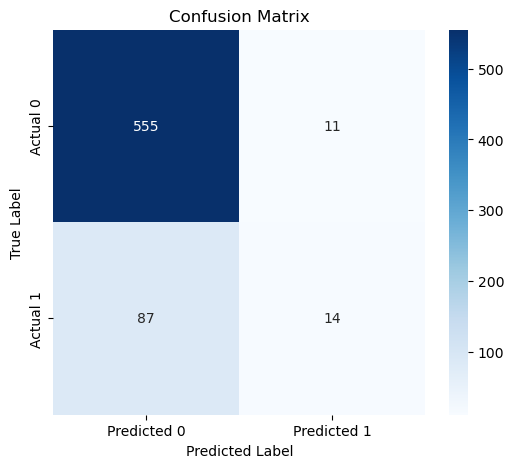

In [38]:
#Let's initialize the model
logreg_model = LogisticRegression(random_state=42)

logreg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logreg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('model 1 (Logistic Regression)')
print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1-score: {f1}")

# Classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

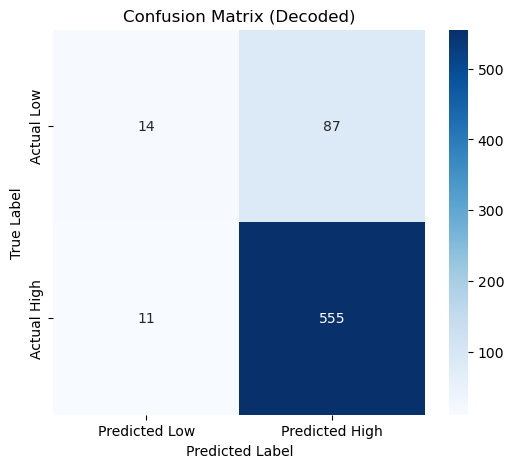

In [39]:
#Let's decode the true labels and predictions
y_test_decoded = y_test.map({0: 'low', 1: 'high'})
y_pred_decoded = pd.Series(y_pred).map({0: 'low', 1: 'high'})

# Plot confusion matrix with decoded labels
cm = confusion_matrix(y_test_decoded, y_pred_decoded)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title("Confusion Matrix (Decoded)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

From our model above, using all the features, we get the following;
1. Accuracy: 0.8470764617691154 (quite high)
2. Recall: 0.1188118811881188 (this is very low as we are only trully capturing 11% of churns)
3. Precision: 0.48 (The model is correctly predicting churns nearly half the time so this very low)
4. F1-score: 0.19047619047619047 (This further proves that both recall and precision aren't performing well)

Let's tune the model

In [40]:
#Let's apply grid search to it.

from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.005, 0.05, 0.5, 5, 15, 20, 150],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Penalty type
    'solver': ['liblinear', 'saga','sag']  # Solver algorithm
}

# Initialize GridSearchCV
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Hyperparameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score}")

# Train a new model with the best hyperparameters
best_logreg_model = LogisticRegression(**best_params)
best_logreg_model.fit(X_train, y_train)

# Evaluate the tuned model
y_pred_tuned = best_logreg_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {accuracy_tuned}")

Best Hyperparameters: {'C': 0.5, 'penalty': 'l2', 'solver': 'saga'}
Best Cross-Validation Score: 0.8657152293216968
Tuned Model Accuracy: 0.8545727136431784


From the above tuning, our model has only improved by 1%

### Random Forest Classifier

Accuracy: 0.9550224887556222
Recall: 0.7425742574257426
Precision: 0.9493670886075949
F1-score: 0.8333333333333334
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97       566
         1.0       0.95      0.74      0.83       101

    accuracy                           0.96       667
   macro avg       0.95      0.87      0.90       667
weighted avg       0.95      0.96      0.95       667



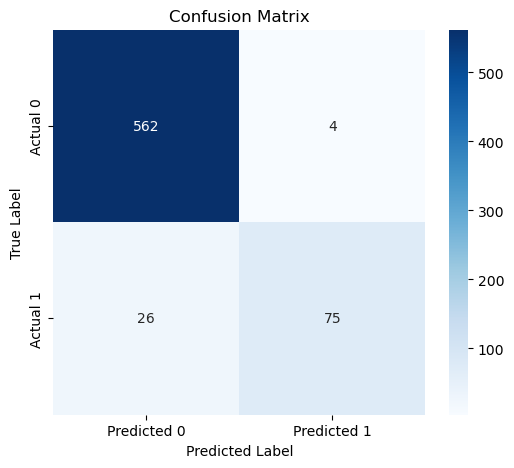

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the random forest classifier
rf_model = RandomForestClassifier(random_state=42)  
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1-score: {f1}")

# Classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Our Random Forest has significantly outperformed the logistical regression especially on recall, precision and F1-score, and as such we can confidently avoid logistical regression for the churn problem.

Let's tune the above model

Best Hyperparameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Score: 0.9561158308212295
Tuned Model Accuracy: 0.9460269865067467
Tuned Model Recall: 0.693069306930693
Tuned Model Precision: 0.9333333333333333
Tuned Model F1-score: 0.7954545454545454
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97       566
         1.0       0.93      0.69      0.80       101

    accuracy                           0.95       667
   macro avg       0.94      0.84      0.88       667
weighted avg       0.95      0.95      0.94       667



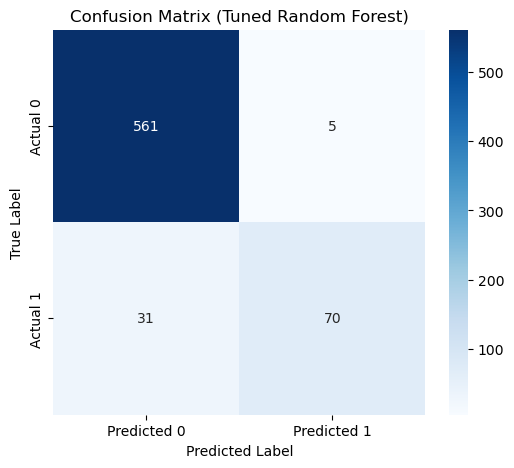

In [42]:

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search_rf.fit(X_train, y_train)

# Get the best hyperparameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"Best Hyperparameters: {best_params_rf}")
print(f"Best Cross-Validation Score: {best_score_rf}")

# Train a new model with the best hyperparameters
best_rf_model = RandomForestClassifier(**best_params_rf, random_state=42)
best_rf_model.fit(X_train, y_train)

# Evaluate the tuned model
y_pred_tuned_rf = best_rf_model.predict(X_test)
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)

print(f"Tuned Model Accuracy: {accuracy_tuned_rf}")
print(f"Tuned Model Recall: {recall_tuned_rf}")
print(f"Tuned Model Precision: {precision_tuned_rf}")
print(f"Tuned Model F1-score: {f1_tuned_rf}")

# Classification report
print(classification_report(y_test, y_pred_tuned_rf))

# Plot confusion matrix
cm_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_tuned_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

After tuning the model, we have seen a drop in our parameters, with recall taking the greatest hit, due to the duration taken to tune (15 minutes) we shall accept the initial model.

### Decision Tree Classifier

Accuracy: 0.9115442278860569
Recall: 0.7326732673267327
Precision: 0.6981132075471698
F1-score: 0.714975845410628
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.95       566
         1.0       0.70      0.73      0.71       101

    accuracy                           0.91       667
   macro avg       0.82      0.84      0.83       667
weighted avg       0.91      0.91      0.91       667



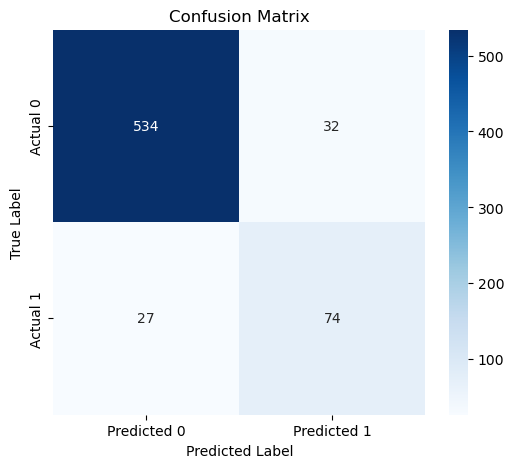

In [43]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the decision tree classifier
dt_model = DecisionTreeClassifier(random_state=42)  
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1-score: {f1}")

# Classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The decision tree has perfromed quite well with accuracy scores of 91%, however recall and precision have dropped.

Let's tune the model

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9373632396652403
Tuned Model Accuracy: 0.9355322338830585
Tuned Model Recall: 0.693069306930693
Tuned Model Precision: 0.8536585365853658
Tuned Model F1-score: 0.7650273224043715
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96       566
         1.0       0.85      0.69      0.77       101

    accuracy                           0.94       667
   macro avg       0.90      0.84      0.86       667
weighted avg       0.93      0.94      0.93       667



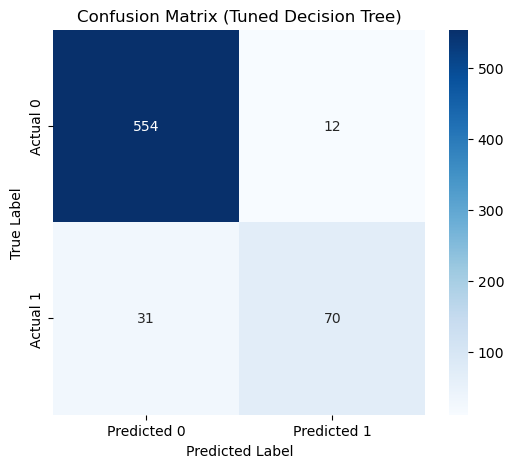

In [44]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search_dt.fit(X_train, y_train)

# Get the best hyperparameters and best score
best_params_dt = grid_search_dt.best_params_
best_score_dt = grid_search_dt.best_score_

print(f"Best Hyperparameters: {best_params_dt}")
print(f"Best Cross-Validation Score: {best_score_dt}")

# Train a new model with the best hyperparameters
best_dt_model = DecisionTreeClassifier(**best_params_dt, random_state=42)
best_dt_model.fit(X_train, y_train)

# Evaluate the tuned model
y_pred_tuned_dt = best_dt_model.predict(X_test)
accuracy_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
recall_tuned_dt = recall_score(y_test, y_pred_tuned_dt)
precision_tuned_dt = precision_score(y_test, y_pred_tuned_dt)
f1_tuned_dt = f1_score(y_test, y_pred_tuned_dt)

print(f"Tuned Model Accuracy: {accuracy_tuned_dt}")
print(f"Tuned Model Recall: {recall_tuned_dt}")
print(f"Tuned Model Precision: {precision_tuned_dt}")
print(f"Tuned Model F1-score: {f1_tuned_dt}")

# Classification report
print(classification_report(y_test, y_pred_tuned_dt))

# Plot confusion matrix
cm_tuned_dt = confusion_matrix(y_test, y_pred_tuned_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm_tuned_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix (Tuned Decision Tree)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# MODEL EVALUATION

The best performing model is Random Forest Clasiffier, Then Decision tree. Logistic regression shouldn't be considered for our modeling;
The results are as follows; 

1. (Logistic Regression) Accuracy: 84% | Recall: 11% | Precision: 48% | F1-Score: 19%
2. (Random Forest Classifier) Accuracy: 95% | Recall: 74% | Precision: 94% | F1-Score: 83%
3. (Decision Tree Classifier) Accuracy: 93% | Recall: 69% | Precision: 85% | F1-Score: 76% 



# CONCLUSION & RECOMMENDATION

Syriatel can confidently deploy the Random Forest Classifier model, along side implementing different customer retention stratedgies such as offers, promotions and advertising as well to test out the success of their various campaigns and to then further adjust accordingly to results received.